In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as Hung

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

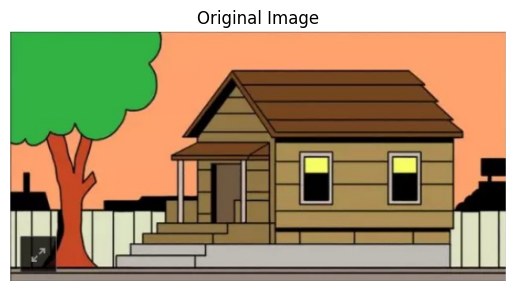

In [2]:
img = cv2.imread('hinh1.jpg')

Hung.imshow(img[:,:,::-1])
Hung.title("Original Image")
Hung.axis('off')

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

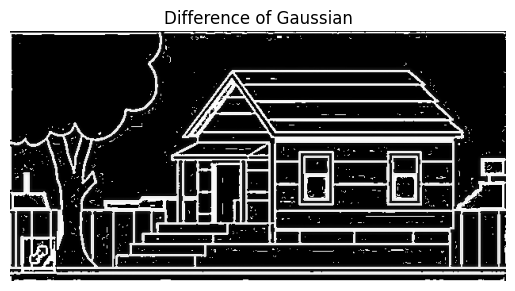

In [3]:
img = cv2.imread('hinh1.jpg',0)

blur1 = cv2.GaussianBlur(img,(5,5),0)
blur2 = cv2.GaussianBlur(img,(9,9),0)

dog = blur1 - blur2

Hung.imshow(dog, cmap='gray')
Hung.title("Difference of Gaussian")
Hung.axis('off')

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

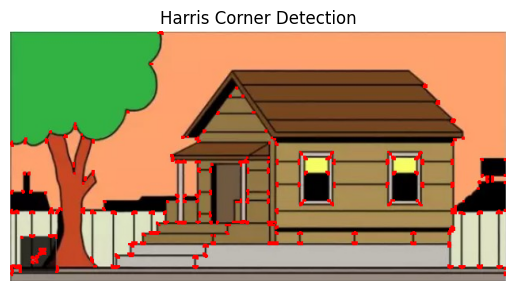

In [5]:
img = cv2.imread('hinh1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)

dst = cv2.dilate(dst,None)

img[dst>0.01*dst.max()] = [0,0,255]

Hung.imshow(img[:,:,::-1])
Hung.title("Harris Corner Detection")
Hung.axis('off')

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

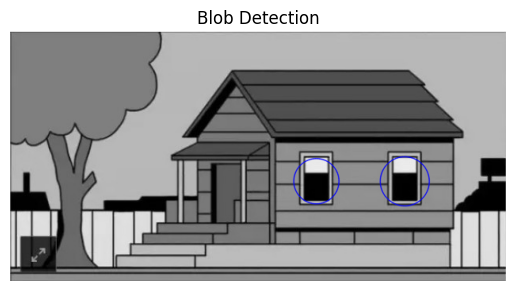

In [6]:
img = cv2.imread('hinh1.jpg',0)

detector = cv2.SimpleBlobDetector_create()
keypoints = detector.detect(img)

img_blob = cv2.drawKeypoints(img, keypoints, np.array([]), (0,0,255),
                             cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

Hung.imshow(img_blob, cmap='gray')
Hung.title("Blob Detection")
Hung.axis('off')

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

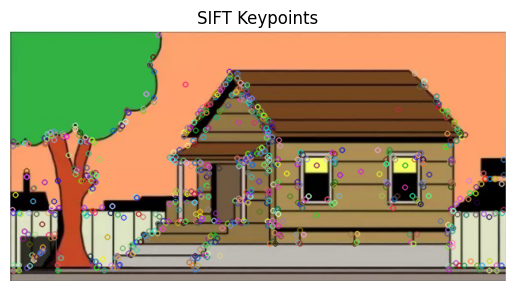

In [7]:
img = cv2.imread('hinh1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray,None)

img_sift = cv2.drawKeypoints(img,kp,None)

Hung.imshow(img_sift[:,:,::-1])
Hung.title("SIFT Keypoints")
Hung.axis('off')

In [12]:
img1 = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img1, img2])

if status == cv2.Stitcher_OK:
    Hung.imshow(pano[:,:,::-1])
    Hung.title("Panorama")
    Hung.axis('off')
else:
    print("Stitching failed, status =", status)

Stitching failed, status = 1


Text(0.5, 1.0, 'Histogram of SIFT Features')

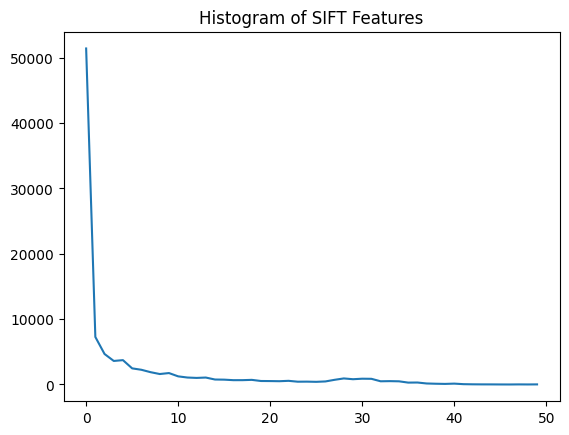

In [10]:
import matplotlib.pyplot as plt

hist = np.histogram(des, bins=50)

plt.plot(hist[0])
plt.title("Histogram of SIFT Features")